Test to see if the firn filter and two timescale ar1 are working.

In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from methane_noise_forcing import simulate_two_timescale_ar1
from methane_noise_forcing.core import FirnFilter

In [3]:
## tunable parameters of noise
tau_x   = 10.0          # e‐folding time of x [years]
tau_eta = 1.0           # e‐folding time of η [years]
variance_x = 225.0      # desired variance of x [ppb^2]
dt      = 1/12          # time step [years]
years   = 1000          # length of each simulation [years]
n_ens   = 10            # number of ensemble members
N       = int(years / dt)

x_ens, eta_ens = simulate_two_timescale_ar1(
    tau_x=tau_x, tau_eta=tau_eta, variance_x=variance_x,
    dt=dt, N=N, n_ens=n_ens)

In [4]:
## check variance of x
variance_x_ens = np.var(x_ens, axis=1)
# calculate mean and standard deviation of variance
mean_variance_x = np.mean(variance_x_ens)
std_variance_x = np.std(variance_x_ens)
print(f"Mean variance of x: {mean_variance_x:.2f} ppb^2")
print(f"Standard deviation of variance of x: {std_variance_x:.2f} ppb^2")

## check variance of eta
variance_eta_ens = np.var(eta_ens, axis=1)
mean_variance_eta = np.mean(variance_eta_ens)
std_variance_eta = np.std(variance_eta_ens)
print(f"Mean variance of η: {mean_variance_eta:.2f} ppb^2 / year^2")
print(f"Standard deviation of variance of η: {std_variance_eta:.2f} ppb^2 / year^2")

Mean variance of x: 227.39 ppb^2
Standard deviation of variance of x: 42.30 ppb^2
Mean variance of η: 24.61 ppb^2 / year^2
Standard deviation of variance of η: 1.13 ppb^2 / year^2


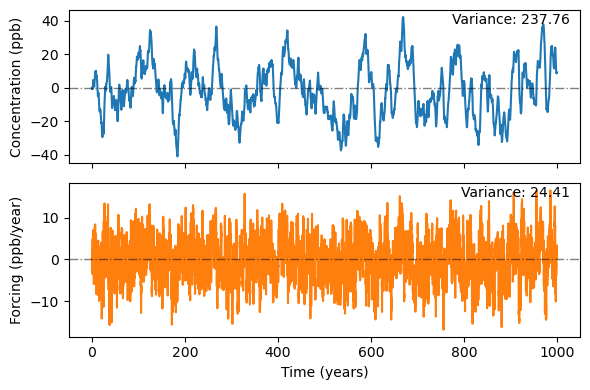

In [5]:
# visualize eta and x
idx_ens = 0

fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
time = np.arange(N) * dt

# Plot x
axs[0].plot(time, x_ens[idx_ens, :], label='x (EM)', color='tab:blue')
axs[0].axhline(0, color='black', lw=1, ls='-.', alpha=0.5)
axs[0].set_ylabel('Concentration (ppb)')
# Calculate and annotate variance of x
var_x = np.var(x_ens[idx_ens, :])
axs[0].text(0.98, 0.98, f'Variance: {var_x:.2f}', ha='right', va='top', 
            transform=axs[0].transAxes)

# Plot eta
axs[1].plot(time, eta_ens[idx_ens, :], label='η (EM)', color='tab:orange')
axs[1].axhline(0, color='black', lw=1, ls='-.', alpha=0.5)
axs[1].set_ylabel('Forcing (ppb/year)')
axs[1].set_xlabel('Time (years)')
# Calculate and annotate variance of eta
var_eta = np.var(eta_ens[idx_ens, :])
axs[1].text(0.98, 0.98, f'Variance: {var_eta:.2f}', ha='right', va='top', 
            transform=axs[1].transAxes)

plt.tight_layout()

In [6]:
## firn filter parameters
mode = 25 # years
fwhm = 22 # years

firn_filter = FirnFilter.from_gamma(mode=mode, fwhm=fwhm, dt=0.5)

# apply firn filter to one ensemble member
idx_ens = 0
x = x_ens[idx_ens, :]
x_smooth = firn_filter.apply(series=x, dt_series=dt)

Text(0.98, 0.98, 'Std: 15.42\nStd(smoothed): 10.39')

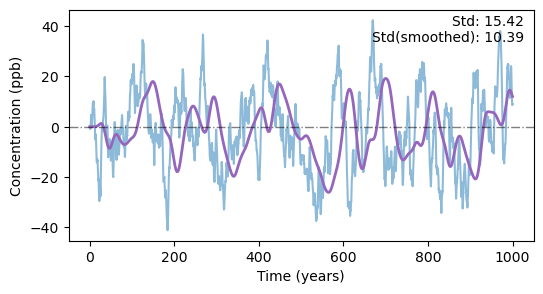

In [7]:
# visualize x and smoothed x
# calculate standard deviation of x and smoothed x
std_x = np.std(x)
std_x_smooth = np.std(x_smooth)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(time, x, label='x', color='tab:blue', alpha=0.5)
ax.plot(time, x_smooth, label='x (smoothed)', color='tab:purple', lw=2)
ax.axhline(0, color='black', lw=1, ls='-.', alpha=0.5)
ax.set_ylabel('Concentration (ppb)')
ax.set_xlabel('Time (years)')

# annotate standard deviation of x and smoothed x
ax.text(0.98, 0.98, f'Std: {std_x:.2f}\n'
                    f'Std(smoothed): {std_x_smooth:.2f}',
        ha='right', va='top', transform=ax.transAxes)

In [8]:
# how correlated is the forcing with x?
idx_ens = 9
correlation = np.corrcoef(x_ens[idx_ens, :], eta_ens[idx_ens, :])[0, 1]
correlation

np.float64(0.35181159062909684)